In [1]:
# ============================================
# 1. ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК
# ============================================

import os
import numpy as np
import warnings
import yaml

import cv2

from ultralytics import YOLO

import torch
from torchvision.ops import box_iou

from sklearn.metrics import precision_recall_curve, auc, roc_curve


warnings.filterwarnings("ignore")

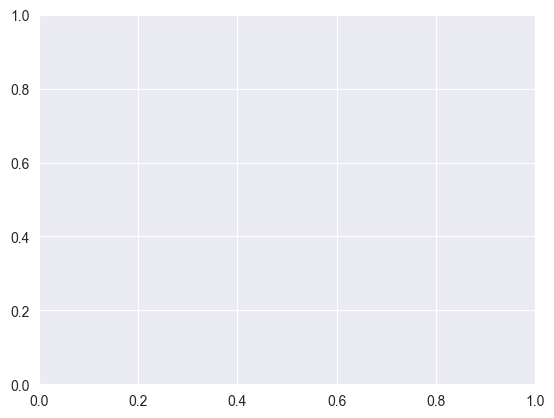

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots()

In [9]:
# ============================================
# 2. ВЫБОР МОДЕЛИ ДЛЯ АНАЛИЗА
# ============================================

MODEL_PATH = 'models/YOLOv8n_augmented/weights/best.pt'
DATASET_YAML_PATH = 'models/dataset_augmented.yaml'
OUTPUT_METRICS_PATH = 'models/YOLOv8n_augmented/yolov8_augmented_metrics'

In [7]:
# ============================================
# 3. БАЗОВАЯ ОЦЕНКА МЕТРИК ТОЧНОСТИ
# ============================================

def base_evaluation_model(model_path, dataset_path, imgsz=(640, 640)):
    model = YOLO(model_path)
    metrics = model.val(
        data=dataset_path,
        split='val',                        # на какой выборке тестировать ('val' или 'test')
        imgsz=imgsz,                          # размер изображения
        batch=16,                            # размер батча
        conf=0.001,                          # порог уверенности
        iou=0.5,                             # порог IoU для NMS
        device='0',                        # устройство ('cuda' или 'cpu')
        workers=8,                            # количество потоков
        plots=True                            # строить графики
    )

    # Вывод метрик
    print(f"mAP50: {metrics.box.map50}")
    print(f"mAP50-95: {metrics.box.map}")
    print(f"Точность: {metrics.box.mp}")
    print(f"Полнота: {metrics.box.mr}")

In [8]:
base_evaluation_model(MODEL_PATH, DATASET_YAML_PATH, imgsz=(640, 640))

WARNING updating to 'imgsz=640'. 'train' and 'val' imgsz must be an integer, while 'predict' and 'export' imgsz may be a [h, w] list or an integer, i.e. 'yolo export imgsz=640,480' or 'yolo export imgsz=640'
Ultralytics 8.3.239  Python-3.13.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 4036.31205.4 MB/s, size: 810.9 KB)
val: Scanning C:\Users\1\Documents\Stud BMSTU\8 semestr\VKR\VKR_project\data\kitti_for_yolo_augmented\labels\val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1497/1497 3.5Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 13.5it/s 7.0s0.1s
                   all       1497       8231      0.855      0.782      0.859      0.601
                       1338       5889      0.931      0.843       0.93      0.703
                  222 

In [10]:
# ============================================
# 4. ПОСТРОЕНИЕ ГРАФИКОВ pd, pfa, DET
# ============================================

def calculate_iou(box1, box2):
    """Вычисляет IoU между двумя боксами в формате [x1,y1,x2,y2]"""
    box1 = torch.tensor([box1], dtype=torch.float32)
    box2 = torch.tensor([box2], dtype=torch.float32)
    return box_iou(box1, box2).item()

def evaluate_model(model, dataset_yaml, conf_thresholds=np.linspace(0.00, 0.95, 11)):
    """Основная функция оценки модели"""
    # Инициализация предсказателя
    temp_result = model.predict(data=dataset_yaml, save=False)
    predictor = model.predictor

    # Получение путей к изображениям и меткам
    with open(dataset_yaml) as f:
        data = yaml.safe_load(f)

    val_image_dir = os.path.join(data['path'], data['val'])
    val_label_dir = val_image_dir.replace('images', 'labels')
    image_files = sorted([f for f in os.listdir(val_image_dir) if f.endswith(('.jpg', '.png'))])

    # Сбор всех данных для метрик
    all_metrics = {
        'scores': [],
        'labels': [],
        'pds': [],
        'pfas': [],
        'precision': [],
        'conf_thresholds': conf_thresholds
    }
    # Проход по всему датасету
    for img_file in image_files:
        img_path = os.path.join(val_image_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Загрузка истинных меток
        label_path = os.path.join(val_label_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))
        gt_boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:  # Проверка формата YOLO (class, x_center, y_center, w, h)
                        class_id, x_center, y_center, width, height = map(float, parts)
                        # Конвертация YOLO -> XYXY
                        x1 = (x_center - width/2) * img.shape[1]
                        y1 = (y_center - height/2) * img.shape[0]
                        x2 = (x_center + width/2) * img.shape[1]
                        y2 = (y_center + height/2) * img.shape[0]
                        gt_boxes.append([x1, y1, x2, y2])

        # Получение предсказаний
        results = model.predict(img, conf=0.01, verbose=False)  # Низкий порог для полной кривой
        if len(results) == 0:
            continue

        pred = results[0]
        pred_boxes = pred.boxes.xyxy.cpu().numpy()
        pred_scores = pred.boxes.conf.cpu().numpy()

        # Сопоставление предсказаний с истинными метками
        matched_gt = set()
        for i, p_box in enumerate(pred_boxes):
            max_iou = 0
            best_match = -1
            for j, g_box in enumerate(gt_boxes):
                iou = calculate_iou(p_box, g_box)
                if iou > max_iou:
                    max_iou = iou
                    best_match = j

            # Сохраняем результаты для Precision-Recall
            if max_iou >= 0.5 and best_match not in matched_gt:
                all_metrics['labels'].append(1)  # True Positive
                matched_gt.add(best_match)
            else:
                all_metrics['labels'].append(0)  # False Positive
            all_metrics['scores'].append(pred_scores[i])

    # Расчет Precision-Recall
    precision, recall, thresholds = precision_recall_curve(all_metrics['labels'], all_metrics['scores'])
    #print(_)
    all_metrics['pr_curve'] = (precision, recall, thresholds)
    all_metrics['ap'] = auc(recall, precision)

    # Расчет Pd и Pfa для разных порогов
    k = 0
    for conf in conf_thresholds:
        print(k)
        k += 1
        tp, fp, fn = 0, 0, 0
        for img_file in image_files:
            img_path = os.path.join(val_image_dir, img_file)
            results = model.predict(img_path, conf=conf, verbose=False)

            # Получаем истинные метки
            label_path = os.path.join(val_label_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))
            gt_boxes = []
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) == 5:
                            class_id, x_center, y_center, width, height = map(float, parts)
                            x1 = (x_center - width/2) * img.shape[1]
                            y1 = (y_center - height/2) * img.shape[0]
                            x2 = (x_center + width/2) * img.shape[1]
                            y2 = (y_center + height/2) * img.shape[0]
                            gt_boxes.append([x1, y1, x2, y2])

            # Обработка предсказаний
            if len(results) > 0:
                pred = results[0]
                pred_boxes = pred.boxes.xyxy.cpu().numpy()

                # Сопоставление
                matched = set()
                for p_box in pred_boxes:
                    max_iou = 0
                    best_match = -1
                    for j, g_box in enumerate(gt_boxes):
                        iou = calculate_iou(p_box, g_box)
                        if iou > max_iou:
                            max_iou = iou
                            best_match = j

                    if max_iou >= 0.5 and best_match not in matched:
                        tp += 1
                        matched.add(best_match)
                    else:
                        fp += 1

                fn += len(gt_boxes) - len(matched)

        pd = tp / (tp + fn) if (tp + fn) > 0 else 0
        pfa = fp / (fp + tp) if (fp + tp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        all_metrics['pds'].append(pd)
        all_metrics['pfas'].append(pfa)
        all_metrics['precision'].append(precision)

    return all_metrics


def plot_metrics(metrics, output_dir):
    """Построение графиков метрик"""
    plt.figure(figsize=(22, 5))

    # Precision-Recall кривая
    plt.subplot(141)
    precision, recall, thresholds = metrics['pr_curve']
    plt.plot(recall, precision, 'b-', linewidth=2, label=f'Площадь под кривой (Average Precision) = {metrics["ap"]:.3f}')
    plt.xlabel('Полнота (Recall)')
    plt.ylabel('Точность (Precision)')
    plt.title('Кривая Точность-Полнота')
    plt.legend()
    plt.grid(True)

    # Кривая Pfa по порогам
    plt.subplot(142)
    plt.plot(metrics['conf_thresholds'], metrics['pfas'], 'r-', linewidth=2)
    plt.xlabel('Порог обнаружения')
    plt.ylabel('Вероятность ложного срабатывания (Pfa)')
    plt.title('Кривая вероятности ложного срабатывания')
    plt.grid(True)

    # Кривая Pd по порогам
    plt.subplot(143)
    plt.plot(metrics['conf_thresholds'], metrics['pds'], 'g-', linewidth=2)
    plt.xlabel('Порог обнаружения')
    plt.ylabel('Вероятность обнаружения (Pd)')
    plt.title('Кривая вероятности обнаружения')
    plt.grid(True)

    # Кривая Pd-Pfa
    plt.subplot(144)
    plt.plot(metrics['pfas'], metrics['pds'], 'b-', linewidth=2)
    plt.xlabel('Вероятность ложного срабатывания (Pfa)')
    plt.ylabel('Вероятность обнаружения (Pd)')
    plt.title('Кривая рабочих характеристик детектора (DET)')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'kitti_pd_pfa.png'))
    plt.show()

WARNING 'source' is missing. Using 'source=C:\Users\1\anaconda3\Lib\site-packages\ultralytics\assets'.

image 1/2 C:\Users\1\anaconda3\Lib\site-packages\ultralytics\assets\bus.jpg: 640x480 (no detections), 59.5ms
image 2/2 C:\Users\1\anaconda3\Lib\site-packages\ultralytics\assets\zidane.jpg: 384x640 (no detections), 46.8ms
Speed: 3.0ms preprocess, 53.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


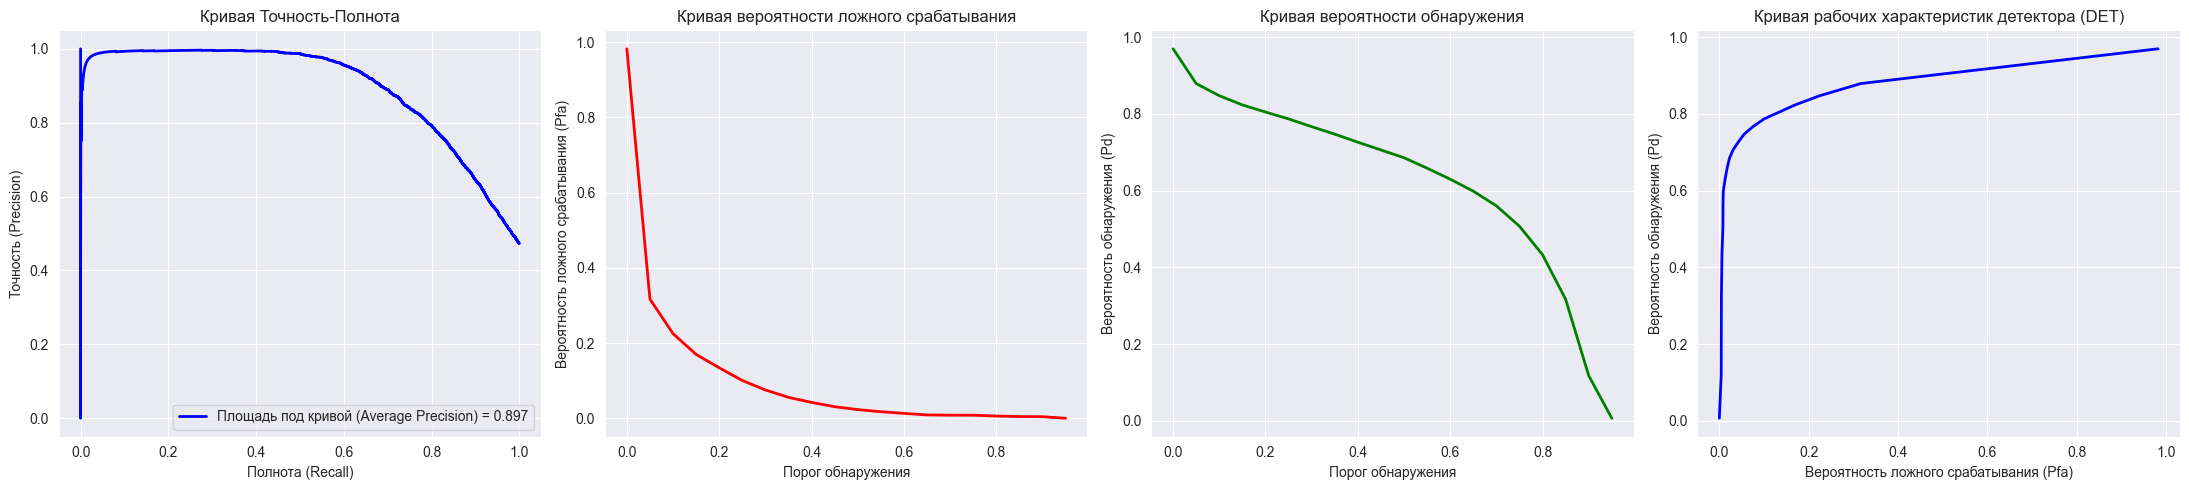

In [11]:
model = YOLO(MODEL_PATH)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

detailed_metrics = evaluate_model(model, DATASET_YAML_PATH, conf_thresholds=np.linspace(0.00, 0.95, 20))
plot_metrics(detailed_metrics, OUTPUT_METRICS_PATH)

In [12]:
np.array(detailed_metrics['pds']).round(5)*100

array([     96.963,      87.912,      84.741,      82.347,      80.488,      78.702,      76.674,       74.73,      72.628,      70.611,      68.582,      65.861,      62.994,      59.871,      56.056,      50.735,      43.312,      31.685,      11.797,       0.705])

In [13]:
np.array(detailed_metrics['pfas']).round(5)*100

array([     98.223,      31.684,        22.5,      16.967,      13.421,       10.04,       7.518,       5.558,       4.214,       3.069,       2.302,        1.74,       1.294,       0.885,       0.817,       0.808,       0.586,       0.458,        0.41,           0])

In [14]:
detailed_metrics['conf_thresholds']

array([          0,        0.05,         0.1,        0.15,         0.2,        0.25,         0.3,        0.35,         0.4,        0.45,         0.5,        0.55,         0.6,        0.65,         0.7,        0.75,         0.8,        0.85,         0.9,        0.95])

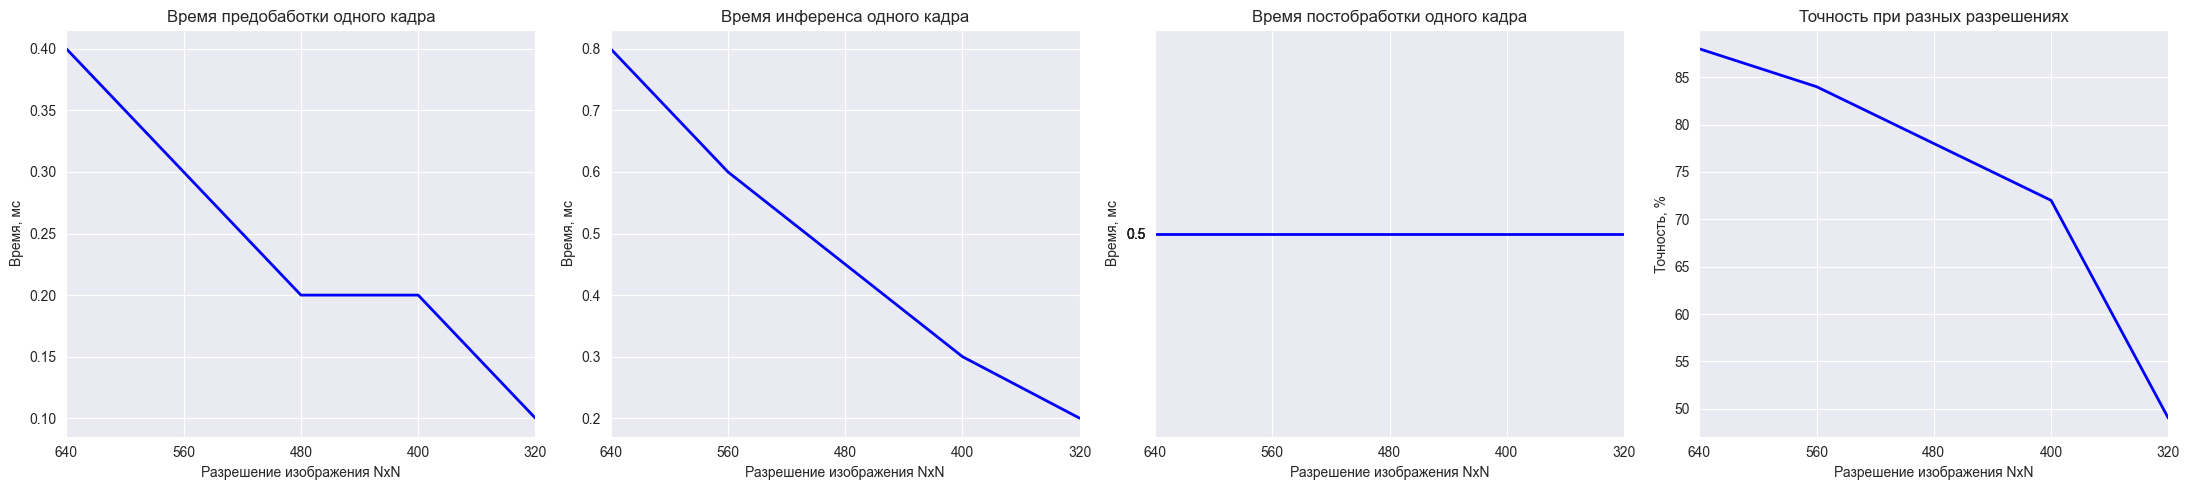

In [26]:
# =======================================================================================
# 5. ПОСТРОЕНИЕ ГРАФИКОВ ЗАВИСИМОСТИ ТОЧНОСТИ И СКОРОСТИ ОТ РАЗМЕРА ВХОДНОГО ИЗОБРАЖЕНИЯ
# =======================================================================================

img_sizes = np.array([640-80*i for i in range(5)])
speed_pre = np.array([0.4, 0.3, 0.2, 0.2, 0.1])
speed_inf = np.array([0.8, 0.6, 0.45, 0.3, 0.2])
speed_ost = np.array([0.5, 0.5, 0.5, 0.5, 0.5])
mAP = np.array([88, 84, 78, 72, 49])

plt.figure(figsize=(22, 5))

plt.subplot(141)
plt.plot(img_sizes, speed_pre, 'b-', linewidth=2)
plt.xlabel('Разрешение изображения NxN')
plt.ylabel('Время, мс')
plt.title('Время предобаботки одного кадра')
plt.xticks(img_sizes)
#plt.yticks(speed_pre)
plt.xlim(max(img_sizes), min(img_sizes))
plt.grid(True)

plt.subplot(142)
plt.plot(img_sizes, speed_inf, 'b-', linewidth=2)
plt.xlabel('Разрешение изображения NxN')
plt.ylabel('Время, мс')
plt.title('Время инференса одного кадра')
plt.xticks(img_sizes)
#plt.yticks(speed_inf)
plt.xlim(max(img_sizes), min(img_sizes))
plt.grid(True)

plt.subplot(143)
plt.plot(img_sizes, speed_ost, 'b-', linewidth=2)
plt.xlabel('Разрешение изображения NxN')
plt.ylabel('Время, мс')
plt.title('Время постобработки одного кадра')
plt.xticks(img_sizes)
plt.yticks(speed_ost)
plt.xlim(max(img_sizes), min(img_sizes))
plt.grid(True)

plt.subplot(144)
plt.plot(img_sizes, mAP, 'b-', linewidth=2)
plt.xlabel('Разрешение изображения NxN')
plt.ylabel('Точность, %')
plt.title('Точность при разных разрешениях')
plt.xticks(img_sizes)
#plt.yticks(mAP)
plt.xlim(max(img_sizes), min(img_sizes))
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join('models/YOLOv8n_dif_pic_sizes', 'speed.png'))
plt.show()